# Two-Point Step Sizes for the Gradient Method: Barzilai–Borwein and Scalar Correction

**Course:** Advanced Numerical Optimization (20.IDI16) · **Mentor:** Prof. Marko Miladinović · **Author:** Elvir Muslić

This notebook extends `bfgs_lbfgs_project.ipynb` and produces every number and the figure of Section 7.7 of the seminar paper. It reuses the main notebook's code unchanged, including the setup, the counted objective, the line search, the solvers and the 15 Vilin test functions. It adds the gradient method with two-point step sizes, in the two variants of Vilin's gradient-descent group (App. A.1):

- the **Barzilai–Borwein** step;
- the **Scalar Correction** step of Miladinović, Stanimirović and Miljković (2011).

Both use the **nonmonotone line search** of Grippo, Lampariello and Lucidi (1986), as in Vilin.

All reported quantities are iteration and evaluation counts, which are deterministic; this notebook reports no timings, so the timing results of the main notebook are left untouched.

Run with `.venv/bin/jupyter nbconvert --to notebook --execute --inplace two_point_steps.ipynb`. The run writes `figures/two_point_profiles.pdf` and `results_two_point.json`.

In [1]:
import ast
import json
from pathlib import Path

MAIN = json.loads(Path("bfgs_lbfgs_project.ipynb").read_text())
MAIN_CODE = ["".join(c["source"]) for c in MAIN["cells"] if c["cell_type"] == "code"]


def main_cell(marker):
    """The unique code cell of the main notebook that contains `marker`."""
    hits = [c for c in MAIN_CODE if marker in c]
    assert len(hits) == 1, f"{marker!r} found in {len(hits)} cells"
    return hits[0]


def main_functions(marker):
    """Only the function definitions of a main-notebook cell (its experiments are not re-run)."""
    tree = ast.parse(main_cell(marker))
    return compile(ast.Module([n for n in tree.body if isinstance(n, ast.FunctionDef)], []), "main", "exec")


exec(main_cell("NOTEBOOK_START = time.perf_counter()"))      # imports, plotting style, check(), save_figure()
GAMMA_LINE = "gamma = sy / float(y @ y)"
solver_src = main_cell("class CountedObjective")
assert solver_src.count(GAMMA_LINE) == 1
exec(solver_src.replace(GAMMA_LINE, "gamma = GAMMA_RULE(s, y, sy, gamma)"))   # L-BFGS scaling made pluggable
GAMMA_RULE = lambda s, y, sy, gamma: sy / float(y @ y)       # the main notebook's rule, N&W (7.20)
exec(main_cell("TEST_SET = {"))
exec(main_cell("def f_star("))
exec(main_functions("def run_benchmark("))                    # performance_profile()
exec(main_functions("def to_jsonable("))
RESULTS = {"environment": RESULTS["environment"]}

# The reuse is exact: re-running the main notebook's steepest descent and L-BFGS reproduces its stored runs.
stored = json.loads(Path("results.json").read_text())["benchmark"]["runs"]
SD_RUNS, LB_RUNS, mismatches = {}, {}, 0
for row in stored:
    if row["method"] not in ("Steepest descent", "L-BFGS (m=5)"):
        continue
    f, g, x0f, _ = TEST_SET[row["problem"]]
    kw = dict(method="sd") if row["method"] == "Steepest descent" else dict(method="lbfgs", m=5)
    r = minimize(f, g, x0f(row["n"]), **kw)
    (SD_RUNS if kw["method"] == "sd" else LB_RUNS)[(row["problem"], row["n"])] = r
    mismatches += (r.iterations, r.nfev, r.ngev, r.converged) != (row["iterations"], row["f evals"], row["g evals"], row["converged"])
check(len(SD_RUNS) == len(LB_RUNS) == 30 and mismatches == 0,
      "the reused code reproduces all 60 stored runs of steepest descent and L-BFGS (iterations, evaluations, status)")

{'python': '3.14.1', 'numpy': '2.5.0', 'scipy': '1.18.0', 'torch': '2.14.1', 'matplotlib': '3.11.0', 'machine': 'arm64'}


check: the reused code reproduces all 60 stored runs of steepest descent and L-BFGS (iterations, evaluations, status) ✓


## The two-point steps

The gradient method takes $x_{k+1} = x_k - t_k g_k$, with $s_k = x_{k+1} - x_k$ and $y_k = g_{k+1} - g_k$.

- **Barzilai–Borwein** (Vilin (A.2)): $t_{k+1} = \dfrac{s_k^\top y_k}{y_k^\top y_k}$, the scalar that best satisfies the secant equation $t\,y_k \approx s_k$ in the least-squares sense. It is the same ratio as the L-BFGS scaling $\gamma_k$ of the main notebook.
- **Scalar Correction** (Miladinović, Stanimirović and Miljković 2011; Vilin (A.3)): with $r_k = s_k - t_k y_k$,
$$t_{k+1} = \frac{s_k^\top r_k}{y_k^\top r_k} \ \text{ if } y_k^\top r_k > 0, \qquad t_{k+1} = \frac{\lVert s_k \rVert}{\lVert y_k \rVert} \ \text{ otherwise}.$$
  Since $s_k = r_k + t_k y_k$, the first case equals $t_k + r_k^\top r_k / y_k^\top r_k$, which corrects the previous scalar by the residual $r_k$ of the secant equation.
- **Nonmonotone line search** (Grippo, Lampariello and Lucidi 1986; Vilin (A.23)): both steps may raise $f$, so a trial $t$ is accepted when
$$f(x_k + t d_k) \le \max_{0 \le j \le m(k)} f(x_{k-j}) + \rho\, t\, g_k^\top d_k, \qquad m(k) \le M - 1,$$
  with $M = 10$ and $\rho = 10^{-4}$. Otherwise $t$ is reduced by safeguarded quadratic interpolation within $[0.1t, 0.5t]$.

The first trial step $\min(1, 1/\lVert g_0 \rVert)$ and the stopping test $\lVert g_k \rVert_2 \le 10^{-5} \max(1, \lVert x_k \rVert_2)$ are those of the main notebook.

In [2]:
def minimize_two_point(fun, grad, x0, rule="sc", M=10, eps=1e-5, max_iter=10_000, rho=1e-4):
    """Gradient method with a two-point step (rule "bb" or "sc") and the nonmonotone Armijo search.
    Same first trial step and stopping test as minimize(); returns the main notebook's Result."""
    obj = CountedObjective(fun, grad)
    t_start = time.perf_counter()
    x = np.array(x0, dtype=float)
    f = obj.f(x)
    g = obj.g(x)
    gnorm = float(np.linalg.norm(g))
    t = min(1.0, 1.0 / gnorm)
    f_recent = deque([f], maxlen=M)                     # f(x_{k-j}), j = 0, ..., m(k)
    hist, status, k = [gnorm], "max_iter", 0
    while k < max_iter:
        if gnorm <= eps * max(1.0, float(np.linalg.norm(x))):
            status = "converged"
            break
        d = -g
        slope = float(g @ d)
        f_ref = max(f_recent)
        a, accepted = t, False
        for _ in range(60):
            f_a = obj.f(x + a * d)
            if np.isfinite(f_a) and f_a <= f_ref + rho * a * slope:
                accepted = True
                break
            den = 2.0 * (f_a - f - a * slope) if np.isfinite(f_a) else 0.0
            a_q = -slope * a * a / den if den > 0.0 else 0.5 * a
            a = min(max(a_q, 0.1 * a), 0.5 * a)          # safeguarded quadratic interpolation
        if not accepted:
            status = "line_search"
            break
        s = a * d
        x = x + s
        g_new = obj.g(x)
        y = g_new - g
        sy = float(s @ y)
        if sy > 1e-12 * np.linalg.norm(s) * np.linalg.norm(y):
            if rule == "bb":
                t = sy / float(y @ y)                       # Vilin (A.2)
            else:
                r = s - t * y                                # Vilin (A.3): t is the scalar used at this step
                yr = float(y @ r)
                t = float(s @ r) / yr if yr > 0.0 else float(np.linalg.norm(s) / np.linalg.norm(y))
        else:
            t = min(1.0, 1.0 / max(float(np.linalg.norm(g_new)), 1e-300))
        t = min(max(t, 1e-10), 1e10)
        f, g = f_a, g_new
        gnorm = float(np.linalg.norm(g))
        f_recent.append(f)
        k += 1
        hist.append(gnorm)
    if status == "max_iter" and gnorm <= eps * max(1.0, float(np.linalg.norm(x))):
        status = "converged"
    name = {"bb": "Barzilai-Borwein", "sc": "Scalar Correction"}[rule]
    return Result(name, x, f, gnorm, k, obj.nfev, obj.ngev, time.perf_counter() - t_start, status, hist, [])


# The Scalar Correction step on the worked pair of Section 3.1: s = (1, 0), y = (2, 1), t = 1/4
s_w, y_w, t_w = np.array([1.0, 0.0]), np.array([2.0, 1.0]), 0.25
r_w = s_w - t_w * y_w
t_sc = float(s_w @ r_w) / float(y_w @ r_w)
check(np.isclose(t_sc, 2.0 / 3.0), f"worked pair: r = {r_w}, y^T r = {y_w @ r_w:.2f}, t_SC = {t_sc:.5f} = 2/3 (BB gives {(s_w @ y_w) / (y_w @ y_w):.2f})")

rng = np.random.default_rng(7)
worst = 0.0
for _ in range(1000):
    s_r, y_r, t_r = rng.standard_normal(6), rng.standard_normal(6), rng.uniform(0.01, 2.0)
    r_r = s_r - t_r * y_r
    if y_r @ r_r > 1e-3:
        a1 = float(s_r @ r_r) / float(y_r @ r_r)
        a2 = t_r + float(r_r @ r_r) / float(y_r @ r_r)
        worst = max(worst, abs(a1 - a2) / max(1.0, abs(a1)))
check(worst < 1e-12, f"t_SC = t + r^T r / y^T r on random pairs (largest relative difference {worst:.1e})")

A = rng.standard_normal((8, 8))
Q = A @ A.T + 0.5 * np.eye(8)
lam = np.linalg.eigvalsh(Q)
inside = all(1 / lam[-1] * (1 - 1e-12) <= float(s @ Q @ s) / float((Q @ s) @ (Q @ s)) <= 1 / lam[0] * (1 + 1e-12)
             for s in rng.standard_normal((1000, 8)))
check(inside, "on a convex quadratic (y = Q s) the Barzilai-Borwein step lies in [1/lambda_max, 1/lambda_min]")

check: worked pair: r = [ 0.5  -0.25], y^T r = 0.75, t_SC = 0.66667 = 2/3 (BB gives 0.40) ✓
check: t_SC = t + r^T r / y^T r on random pairs (largest relative difference 3.3e-16) ✓
check: on a convex quadratic (y = Q s) the Barzilai-Borwein step lies in [1/lambda_max, 1/lambda_min] ✓


## Benchmark: the gradient method with and without two-point steps

The 15 Vilin functions at $n = 100$ and $n = 1000$, from Vilin's starting points, with the stopping test of the main notebook. Steepest descent and L-BFGS ($m = 5$) are the main notebook's runs, reproduced above. A method *solves* a problem when it meets the stopping test within 10 000 iterations. Ratios are geometric means over the problems that both methods solve.

In [3]:
rows = []
for n in (100, 1000):
    for name, (f, g, x0f, _) in TEST_SET.items():
        x0 = x0f(n)
        runs = {"Steepest descent": SD_RUNS[(name, n)],
                "Barzilai-Borwein": minimize_two_point(f, g, x0, rule="bb"),
                "Scalar Correction": minimize_two_point(f, g, x0, rule="sc"),
                "L-BFGS (m=5)": LB_RUNS[(name, n)]}
        fs = f_star(name, n)
        for label, r in runs.items():
            rows.append({"problem": name, "n": n, "method": label, "converged": r.converged, "status": r.status,
                         "iterations": r.iterations, "f evals": r.nfev, "g evals": r.ngev,
                         "evaluations": r.nfev + r.ngev,
                         "gap": None if fs is None else abs(r.f - fs) / max(1.0, abs(fs))})
tp = pd.DataFrame(rows)
ORDER = ["Steepest descent", "Barzilai-Borwein", "Scalar Correction", "L-BFGS (m=5)"]


def geo_ratio(n, method, base, metric):
    a = tp[(tp.n == n) & (tp.method == method)].set_index("problem")
    b = tp[(tp.n == n) & (tp.method == base)].set_index("problem")
    both = a.converged & b.converged
    return float(np.exp(np.mean(np.log(a[metric][both] / b[metric][both])))), int(both.sum())


summary = {}
for n in (100, 1000):
    summary[n] = {}
    for m in ORDER:
        sub = tp[(tp.n == n) & (tp.method == m)]
        entry = {"solved": int(sub.converged.sum()),
                 "iterations_on_solved": int(sub[sub.converged].iterations.sum()),
                 "evaluations_on_solved": int(sub[sub.converged].evaluations.sum())}
        if m != "Steepest descent":
            (ri, c), (re_, _) = geo_ratio(n, m, "Steepest descent", "iterations"), geo_ratio(n, m, "Steepest descent", "evaluations")
            entry.update({"vs_steepest_descent_problems": c, "iteration_ratio": ri, "evaluation_ratio": re_})
        if m != "L-BFGS (m=5)":
            (li, lc), (le, _) = geo_ratio(n, m, "L-BFGS (m=5)", "iterations"), geo_ratio(n, m, "L-BFGS (m=5)", "evaluations")
            entry.update({"vs_lbfgs_problems": lc, "iteration_ratio_vs_lbfgs": li, "evaluation_ratio_vs_lbfgs": le})
        best = tp[(tp.n == n) & tp.converged].groupby("problem").iterations.min()
        mine = sub.set_index("problem")
        entry["within_4x_of_best"] = int(sum(bool(mine.converged[p]) and mine.iterations[p] <= 4 * best[p] for p in mine.index))
        summary[n][m] = entry
    print(f"n = {n}")
    print(pd.DataFrame(summary[n]).T.to_string(float_format=lambda v: f"{v:.3f}"), "\n")

per_problem = tp.pivot(index="problem", columns=["n", "method"], values="iterations")
print("Iterations per problem (10 000 = not solved):\n", per_problem.to_string())

for n in (100, 1000):
    check(summary[n]["Steepest descent"]["solved"] == {100: 12, 1000: 7}[n],
          f"n = {n}: steepest descent solves {summary[n]['Steepest descent']['solved']} of 15, as in Section 7.3")
    for m in ("Barzilai-Borwein", "Scalar Correction"):
        check(summary[n][m]["solved"] >= 14, f"n = {n}: {m} solves {summary[n][m]['solved']} of 15")
        check(summary[n][m]["iteration_ratio"] <= 0.2,
              f"n = {n}: {m} needs {summary[n][m]['iteration_ratio']:.3f} of the iterations of steepest descent (geometric mean)")
        a = tp[(tp.n == n) & (tp.method == m)].set_index("problem")
        b = tp[(tp.n == n) & (tp.method == "Steepest descent")].set_index("problem")
        both = a.converged & b.converged
        check(bool((a.iterations[both] < b.iterations[both]).all()),
              f"n = {n}: {m} needs fewer iterations than steepest descent on every one of the {int(both.sum())} problems both solve")

conv = tp[tp.method.isin(["Barzilai-Borwein", "Scalar Correction"]) & tp.converged & tp.gap.notna()]
loose = conv[conv.gap > 1e-4]
check(set(zip(loose.problem, loose.n)) <= {("DIXON3DQ", 1000)} and float(conv.gap.max()) <= 2e-3,
      f"converged two-point runs reach f* to a relative gap <= 1e-4, except DIXON3DQ at n = 1000 (gap {float(loose.gap.max()) if len(loose) else 0:.1e})")
dixon = tp[(tp.problem == "DIXON3DQ") & (tp.n == 1000)].set_index("method")[["converged", "iterations", "gap"]]
print("\nDIXON3DQ, n = 1000 (the stopping test is loose here, Section 5.2):\n", dixon.to_string())

n = 100
                   solved  iterations_on_solved  evaluations_on_solved  vs_lbfgs_problems  iteration_ratio_vs_lbfgs  evaluation_ratio_vs_lbfgs  within_4x_of_best  vs_steepest_descent_problems  iteration_ratio  evaluation_ratio
Steepest descent   12.000             27791.000              56976.000             12.000                    17.718                     17.788              2.000                           NaN              NaN               NaN
Barzilai-Borwein   15.000              7845.000              15978.000             15.000                     2.056                      1.891             14.000                        12.000            0.103             0.094
Scalar Correction  15.000              3995.000               8600.000             15.000                     2.108                      2.002             13.000                        12.000            0.109             0.103
L-BFGS (m=5)       15.000              1321.000               2860.000              

## Rosenbrock, the effect of the nonmonotone memory, and the L-BFGS scaling

- The two-dimensional Rosenbrock function, with the same stopping test.
- The Scalar Correction method with the monotone Armijo rule ($M = 1$) and with nonmonotone memories $M = 5, 10, 20$, to see whether the gain comes from the step or from the line search.
- The same scalars as the initial matrix $H_k^0 = \gamma_k I$ of L-BFGS, to test the main notebook's choice $\gamma_k = s^\top y / y^\top y$ (N&W (7.20)).

In [4]:
f_r, g_r, x0f_r, _ = TEST_SET["ExtRosenbrock"]
rosen = {"Steepest descent": minimize(f_r, g_r, x0f_r(2), method="sd"),
         "Barzilai-Borwein": minimize_two_point(f_r, g_r, x0f_r(2), rule="bb"),
         "Scalar Correction": minimize_two_point(f_r, g_r, x0f_r(2), rule="sc")}
print("Rosenbrock, n = 2:", {k: (v.iterations, v.converged) for k, v in rosen.items()})
check(all(r.converged for r in rosen.values()) and rosen["Scalar Correction"].iterations * 50 < rosen["Steepest descent"].iterations,
      f"Rosenbrock (n = 2): Scalar Correction {rosen['Scalar Correction'].iterations} iterations, "
      f"steepest descent {rosen['Steepest descent'].iterations}")

memory = {}
for n in (100, 1000):
    for M in (1, 5, 10, 20):
        runs = [minimize_two_point(f, g, x0f(n), rule="sc", M=M) for f, g, x0f, _ in TEST_SET.values()]
        memory[f"n={n}, M={M}"] = {"solved": sum(r.converged for r in runs),
                                   "iterations_on_solved": sum(r.iterations for r in runs if r.converged),
                                   "evaluations_on_solved": sum(r.nfev + r.ngev for r in runs if r.converged)}
print(pd.DataFrame(memory).T.to_string())
check(memory["n=100, M=1"]["solved"] == 15 and memory["n=1000, M=1"]["solved"] == 14,
      "with the monotone Armijo rule (M = 1) Scalar Correction still solves 15 and 14 of 15: the gain comes from the step")

GAMMAS = {"s^T y / y^T y (main notebook)": lambda s, y, sy, gamma: sy / float(y @ y),
          "s^T s / s^T y": lambda s, y, sy, gamma: float(s @ s) / sy,
          "Scalar Correction": lambda s, y, sy, gamma: (float(s @ (s - gamma * y)) / float(y @ (s - gamma * y))
                                                        if float(y @ (s - gamma * y)) > 0 else float(np.linalg.norm(s) / np.linalg.norm(y)))}
scaling = {}
for label, rule in GAMMAS.items():
    GAMMA_RULE = rule
    for n in (100, 1000):
        runs = {name: minimize(f, g, x0f(n), method="lbfgs", m=5) for name, (f, g, x0f, _) in TEST_SET.items()}
        base = {name: LB_RUNS[(name, n)] for name in TEST_SET}
        both = [p for p in runs if runs[p].converged and base[p].converged]
        scaling[f"n={n}: {label}"] = {
            "solved": sum(r.converged for r in runs.values()),
            "iteration_ratio": float(np.exp(np.mean([np.log(runs[p].iterations / base[p].iterations) for p in both]))),
            "evaluation_ratio": float(np.exp(np.mean([np.log((runs[p].nfev + runs[p].ngev) / (base[p].nfev + base[p].ngev)) for p in both])))}
GAMMA_RULE = GAMMAS["s^T y / y^T y (main notebook)"]
print(pd.DataFrame(scaling).T.to_string(float_format=lambda v: f"{v:.3f}"))
check(all(v["evaluation_ratio"] > 1.0 for k, v in scaling.items() if "main notebook" not in k),
      "neither alternative scaling reduces the evaluations of L-BFGS: N&W (7.20) stays the best of the three")

Rosenbrock, n = 2: {'Steepest descent': (8261, True), 'Barzilai-Borwein': (80, True), 'Scalar Correction': (74, True)}
check: Rosenbrock (n = 2): Scalar Correction 74 iterations, steepest descent 8261 ✓


              solved  iterations_on_solved  evaluations_on_solved
n=100, M=1        15                  5000                  11535
n=100, M=5        15                  3980                   8688
n=100, M=10       15                  3995                   8600
n=100, M=20       15                  3897                   8189
n=1000, M=1       14                  5039                  11741
n=1000, M=5       14                  3565                   7860
n=1000, M=10      14                  3950                   8520
n=1000, M=20      14                  4502                   9448
check: with the monotone Armijo rule (M = 1) Scalar Correction still solves 15 and 14 of 15: the gain comes from the step ✓


                                       solved  iteration_ratio  evaluation_ratio
n=100: s^T y / y^T y (main notebook)   15.000            1.000             1.000
n=1000: s^T y / y^T y (main notebook)  15.000            1.000             1.000
n=100: s^T s / s^T y                   15.000            0.930             1.178
n=1000: s^T s / s^T y                  14.000            0.848             1.141
n=100: Scalar Correction               15.000            0.969             1.103
n=1000: Scalar Correction              14.000            0.904             1.082
check: neither alternative scaling reduces the evaluations of L-BFGS: N&W (7.20) stays the best of the three ✓


## Performance profiles

Dolan–Moré profiles of the iteration counts, as in Section 7.3; L-BFGS ($m = 5$) is shown for reference.

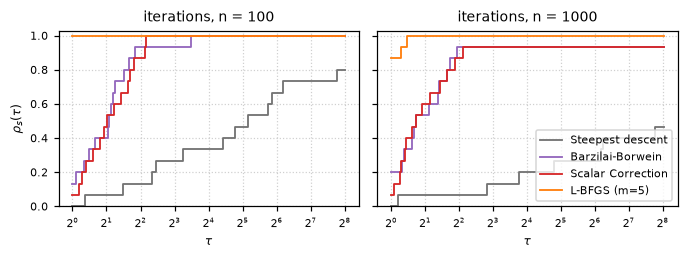

n = 100: {'Steepest descent': (0.0, 0.8), 'Barzilai-Borwein': (0.133, 1.0), 'Scalar Correction': (0.067, 1.0), 'L-BFGS (m=5)': (1.0, 1.0)}
n = 1000: {'Steepest descent': (0.0, 0.467), 'Barzilai-Borwein': (0.2, 0.933), 'Scalar Correction': (0.067, 0.933), 'L-BFGS (m=5)': (0.867, 1.0)}


In [5]:
COLORS.update({"Barzilai-Borwein": "C4", "Scalar Correction": "C3"})
fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.4), sharey=True)
profiles = {}
for ax, n in zip(axes, (100, 1000)):
    profiles[n] = performance_profile(tp[tp.n == n], "iterations", ax, f"iterations, n = {n}", ORDER)
axes[0].set_ylabel(r"$\rho_s(\tau)$")
axes[1].legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "two_point_profiles.pdf")
for n, prof in profiles.items():
    print(f"n = {n}:", {k: (round(v["best_fraction"], 3), round(v["solved_fraction"], 3)) for k, v in prof.items()})

In [6]:
RESULTS.update({
    "summary": summary,
    "runs": rows,
    "rosenbrock_n2": {k: {"iterations": v.iterations, "f evals": v.nfev, "g evals": v.ngev, "converged": v.converged}
                      for k, v in rosen.items()},
    "nonmonotone_memory": memory,
    "lbfgs_scaling": scaling,
    "profiles": profiles,
    "settings": {"M": 10, "rho": 1e-4, "safeguard_interval": [0.1, 0.5], "eps": 1e-5, "max_iter": 10_000},
})
Path("results_two_point.json").write_text(json.dumps(to_jsonable(RESULTS), indent=1, ensure_ascii=False))
print("results_two_point.json written")

results_two_point.json written
